C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



🔄 Processing Apple...


13:41:41 - cmdstanpy - INFO - Chain [1] start processing
13:41:48 - cmdstanpy - INFO - Chain [1] done processing


Test RMSE: 221.2582 | MAE: 173.6566 | MAPE: 89.73%
✅ Saved results for Apple

🔄 Processing GeneralElectric...


13:41:51 - cmdstanpy - INFO - Chain [1] start processing
13:41:57 - cmdstanpy - INFO - Chain [1] done processing


...

Test RMSE: 71.9163 | MAE: 52.5468 | MAPE: 27.89%
✅ Saved results for IBM

🔄 Processing Johnson&Johnson...


13:42:07 - cmdstanpy - INFO - Chain [1] start processing
13:42:10 - cmdstanpy - INFO - Chain [1] done processing


Test RMSE: 22.7611 | MAE: 18.4224 | MAPE: 12.25%
✅ Saved results for Johnson&Johnson

🔄 Processing Microsoft...


13:42:14 - cmdstanpy - INFO - Chain [1] start processing
13:42:17 - cmdstanpy - INFO - Chain [1] done processing


Test RMSE: 270.9519 | MAE: 223.0294 | MAPE: 61.91%
✅ Saved results for Microsoft

📊 RMSE/MAE/MAPE summary for all stocks:
             Stock        RMSE         MAE       MAPE
0            Apple  221.258227  173.656603  89.733995
1  GeneralElectric   88.079785   64.103810  45.949424
2              IBM   71.916296   52.546803  27.885281
3  Johnson&Johnson   22.761065   18.422401  12.250987
4        Microsoft  270.951885  223.029411  61.912743

✅ All stocks processed. Optimized Prophet results saved in Prophet_Results/


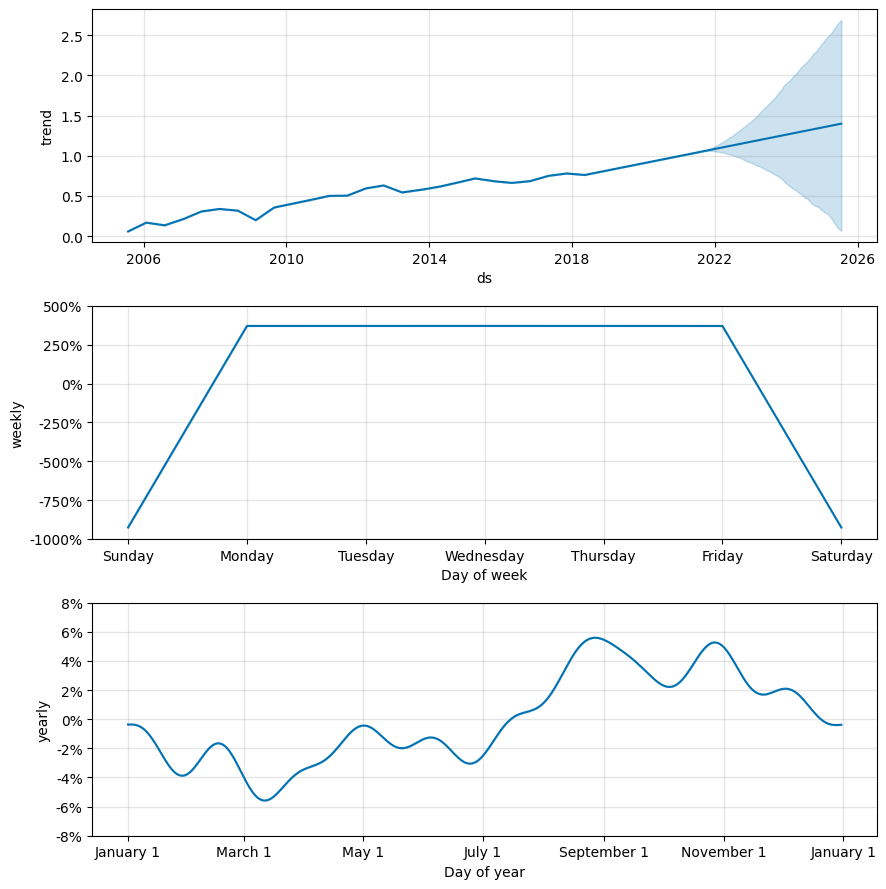

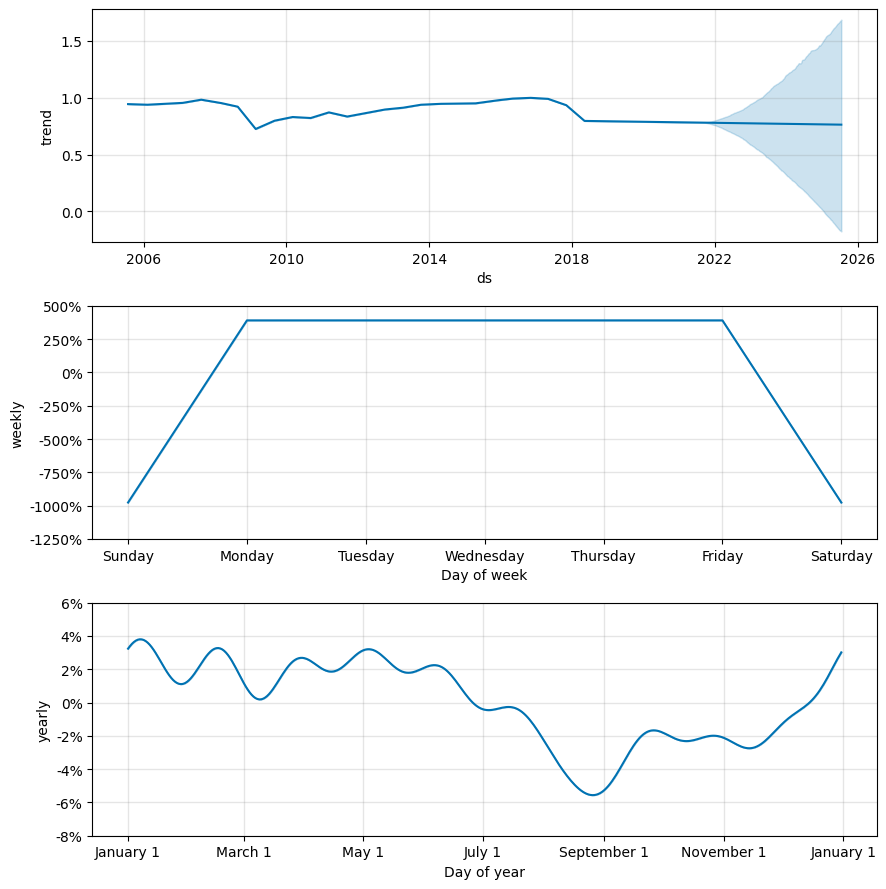

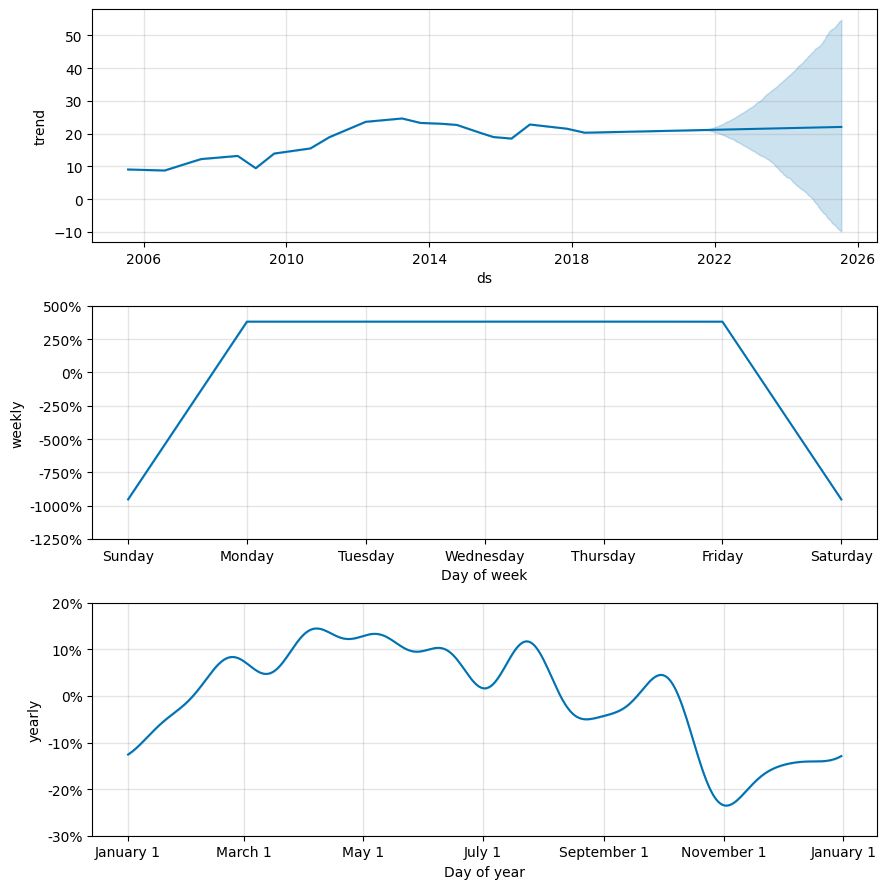

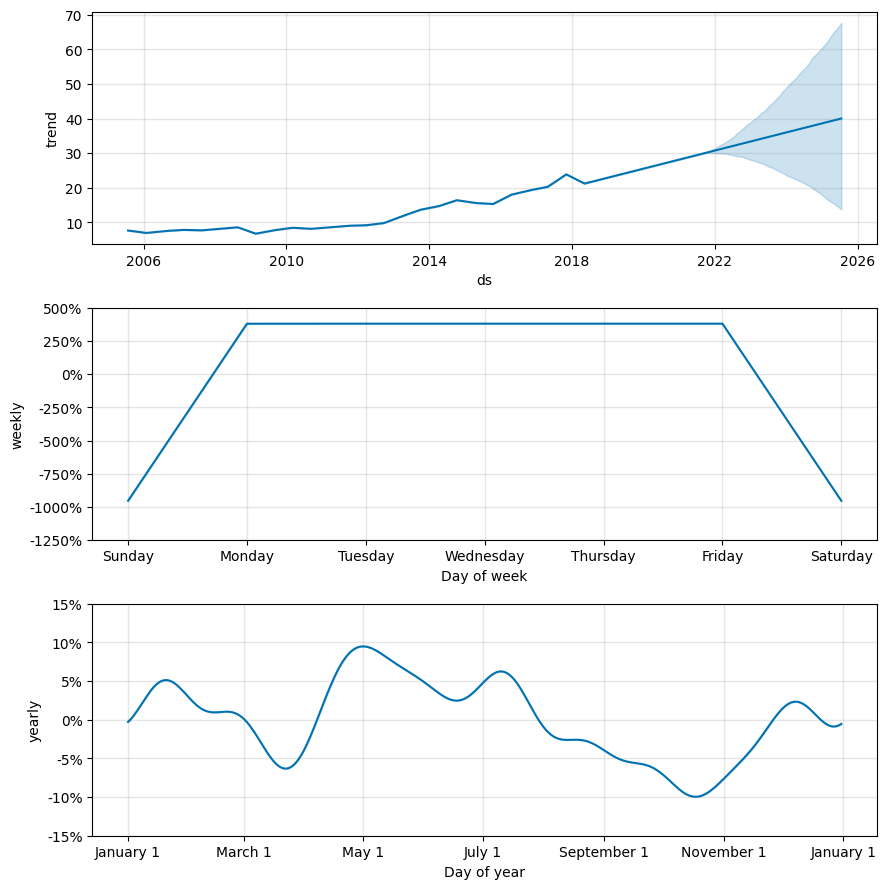

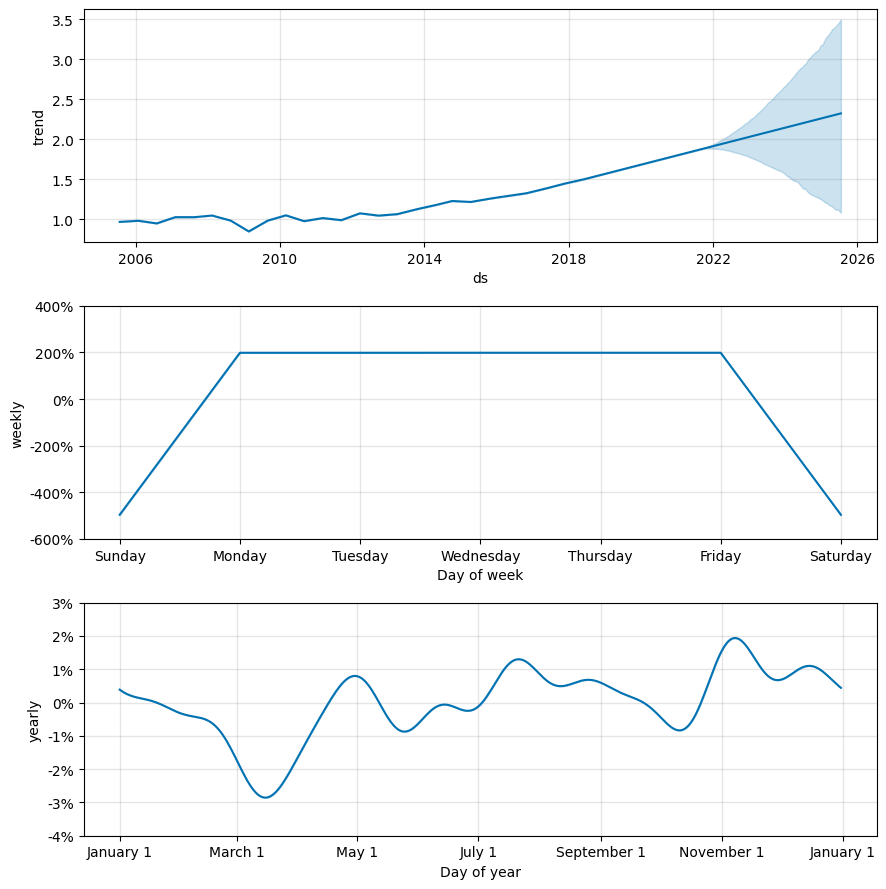

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
from concurrent.futures import ProcessPoolExecutor

warnings.filterwarnings("ignore")

# Grid search parameters
p = d = q = P = D = Q = [0, 1]
seasonal_periods = [5, 7]  # Weekly or trading week seasonality

input_dir = "../Data/SARIMA"
output_dir = "SARIMA_Results"
os.makedirs(output_dir, exist_ok=True)

def sarima_grid_search(train, test, seasonal_period):
    best_score = float("inf")
    best_cfg = None
    best_forecast = None
    for pi in p:
        for di in d:
            for qi in q:
                for Pi in P:
                    for Di in D:
                        for Qi in Q:
                            try:
                                model = SARIMAX(
                                    train,
                                    order=(pi, di, qi),
                                    seasonal_order=(Pi, Di, Qi, seasonal_period),
                                    enforce_stationarity=False,
                                    enforce_invertibility=False
                                ).fit(disp=False)
                                forecast = model.forecast(steps=len(test))
                                rmse = np.sqrt(mean_squared_error(test, forecast))
                                if rmse < best_score:
                                    best_score = rmse
                                    best_cfg = (pi, di, qi, Pi, Di, Qi, seasonal_period)
                                    best_forecast = forecast
                            except Exception as e:
                                continue
    return best_cfg, best_score, best_forecast

def process_stock(file):
    try:
        if not file.endswith("_cleaned.csv"):
            return
        stock = file.replace("_cleaned.csv", "")
        print(f"\n🔄 Processing {stock}...")

        df = pd.read_csv(os.path.join(input_dir, file), index_col='Date', parse_dates=True)
        print(f"Loaded {len(df)} rows for {stock}")
        series = df['Close'] if 'Close' in df.columns else df.iloc[:, 0]

        # Log transform to stabilize variance
        series_log = np.log(series.replace(0, np.nan).dropna())
        use_log = True
        if len(series_log) < int(0.7 * len(series)):
            print(f"⚠️ Skipping log-transform for {stock} (too many zeros or NaNs)")
            series_log = series.copy()
            use_log = False

        # Train-test split (80/20)
        split_idx = int(len(series_log) * 0.8)
        train, test = series_log.iloc[:split_idx], series_log.iloc[split_idx:]

        # Grid search SARIMA
        best_cfg, best_rmse, best_forecast = None, None, None
        for s in seasonal_periods:
            cfg, rmse, forecast = sarima_grid_search(train, test, s)
            if best_rmse is None or rmse < best_rmse:
                best_cfg, best_rmse, best_forecast, best_s = cfg, rmse, forecast, s

        # Inverse log transform if log was used
        if use_log:
            train_actual = np.exp(train)
            test_actual = np.exp(test)
            test_forecast = np.exp(best_forecast)
        else:
            train_actual = train
            test_actual = test
            test_forecast = best_forecast

        # Evaluation
        mae = mean_absolute_error(test_actual, test_forecast)
        print(f"Best SARIMA order for {stock}: {best_cfg}")
        print(f"Test RMSE: {best_rmse:.4f} | MAE: {mae:.4f}")

        # Visualization (full train and test period)
        plt.figure(figsize=(12, 6))
        plt.plot(train_actual.index, train_actual.values, label="Train", color="blue", linewidth=2)
        plt.plot(test_actual.index, test_actual.values, label="Test Actual", color="green", linewidth=2)
        plt.plot(test_actual.index, test_forecast.values, label="Test Forecast", color="red", linestyle='--', linewidth=2)
        plt.title(f"{stock} SARIMA Forecast")
        plt.xlabel("Date")
        plt.ylabel("Price")
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"{output_dir}/{stock}_sarima_forecast.png")
        plt.close()

        # Save forecast results
        out_df = pd.DataFrame({
            "Date": test_actual.index,
            "Actual": test_actual.values,
            "Forecast": test_forecast.values
        })
        out_df.to_csv(f"{output_dir}/{stock}_sarima_forecast.csv", index=False)
        print(f"✅ Saved results for {stock}")

    except Exception as e:
        print(f"❌ Error processing {file}: {e}")

# Parallel processing for all stocks
files = [f for f in os.listdir(input_dir) if f.endswith("_cleaned.csv")]
for f in files:
    process_stock(f)

print("\n✅ All stocks processed. SARIMA results saved in SARIMA_Results")